# Plot AR7W Line from llc1080 Model

In [35]:
## import required packages
import xarray as xr
import s3fs
import zarr
import numpy as np
import netCDF4 as nc4
import boto3
import time
from pathlib import Path
from pyproj import Geod
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [5]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:44797")
client

<Client: 'tcp://127.0.0.1:44797' processes=8 threads=32, memory=123.95 GiB>

In [6]:
# open PHIBOT
s3_path = 's3://ecco-processed-data/SASSIE/N1/GREENLAND/ZARR/PHIBOT_AVG_DAILY.ZARR/'
phibot_ds = xr.open_zarr(s3_path)
phibot_da = phibot_ds.PHIBOT.isel(face=2)

# open ETAN
s3_path = 's3://ecco-processed-data/SASSIE/N1/GREENLAND/ZARR/ETAN_AVG_DAILY.ZARR/'
etan_ds = xr.open_zarr(s3_path)
etan_da = etan_ds.ETAN.isel(face=2)

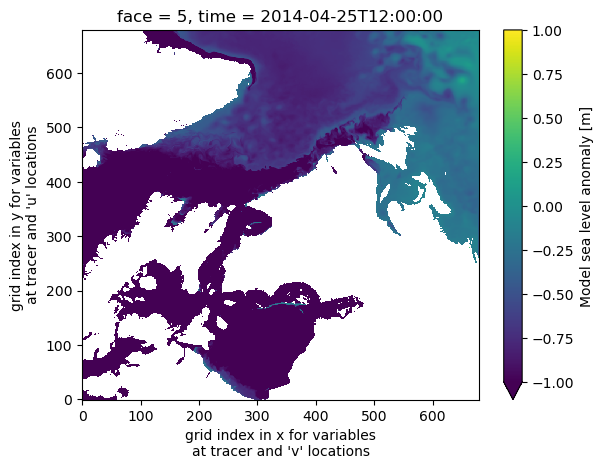

In [56]:
etan_da.isel(time=100).plot(vmin=-1,vmax=1);

In [66]:
# chunk for better processing
etan_da = etan_da.chunk({'time': -1, 'j': 50, 'i': 50})

In [68]:
etan_da

<xarray.DataArray 'ETAN' (time: 2581, j: 680, i: 680)> Size: 10GB
dask.array<rechunk-merge, shape=(2581, 680, 680), dtype=float64, chunksize=(2581, 50, 50), chunktype=numpy.ndarray>
Coordinates:
    XC       (j, i) float32 2MB dask.array<chunksize=(50, 50), meta=np.ndarray>
    YC       (j, i) float32 2MB dask.array<chunksize=(50, 50), meta=np.ndarray>
    face     int32 4B 5
  * i        (i) int32 3kB 0 1 2 3 4 5 6 7 8 ... 672 673 674 675 676 677 678 679
  * j        (j) int32 3kB 0 1 2 3 4 5 6 7 8 ... 672 673 674 675 676 677 678 679
  * time     (time) datetime64[ns] 21kB 2014-01-15T12:00:00 ... 2021-02-07T12...
Attributes:
    comment:                Model sea level anomaly WITHOUT corrections for g...
    coverage_content_type:  modelResult
    long_name:              Model sea level anomaly
    units:                  m

In [67]:
# remove linear trend
p = etan_da.polyfit(dim='time', deg=1)
linear_fit = xr.polyval(etan_da.time, p.polyfit_coefficients)
etan_detrended = etan_da - linear_fit

# remove seasonal cycle
seasonal_cycle = etan_detrended.groupby('time.month').mean('time')
etan_anomaly = etan_detrended.groupby('time.month') - seasonal_cycle

/home/jpluser/miniforge3/envs/jupyter/lib/python3.11/site-packages/dask/array/core.py:4836: PerformanceWarning: Increasing number of chunks by factor of 14
  result = blockwise(


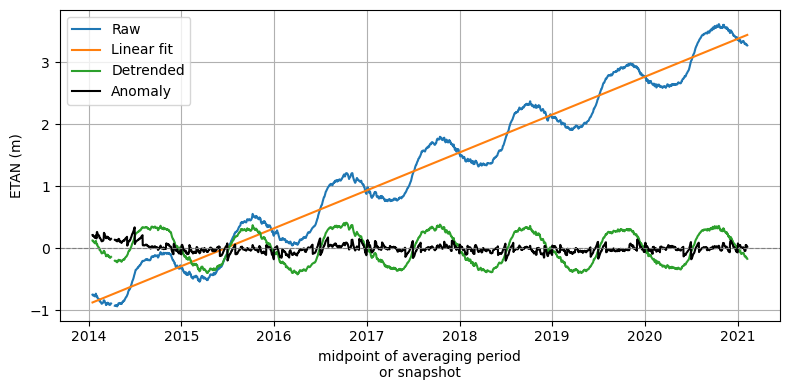

In [69]:
fig, ax = plt.subplots(figsize=(8, 4))

etan_da.mean(dim=['j', 'i']).plot(ax=ax, label='Raw')
linear_fit.mean(dim=['j', 'i']).plot(ax=ax, label='Linear fit')
etan_detrended.mean(dim=['j', 'i']).plot(ax=ax, label='Detrended')
etan_anomaly.mean(dim=['j', 'i']).plot(ax=ax, label='Anomaly', color='k')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylabel('ETAN (m)')
ax.legend()
ax.grid()
plt.tight_layout()

In [76]:
etan_anomaly.name = 'etan_anomaly'

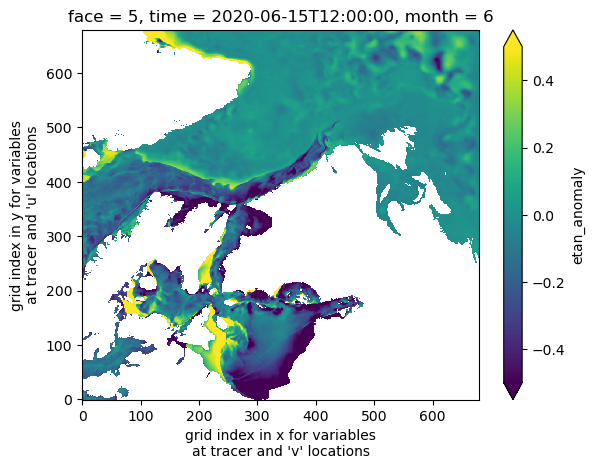

In [87]:
etan_anomaly.sel(time='2020-06-15').plot(vmin=-0.5,vmax=0.5);

In [ ]:
# save ETAN anomaly
etan_anomaly.to_netcdf('~/efs-mount-point/mzahn/data/ar7w/llc1080_etan_tile5_linear_and_seasonal_detrended.nc')

### Isolate transect data from raw ETAN product

In [ ]:
# -----------------------------
# 1. Define transect endpoints
# -----------------------------
lat1, lon1 = 54.0, -55.5
lat2, lon2 = 60.5, -48.0

geod = Geod(ellps="WGS84")

# total distance
_, _, total_dist = geod.inv(lon1, lat1, lon2, lat2)

spacing = 10_000  # 10 km
npts = int(total_dist // spacing) + 1

# intermediate geodesic points
pts = geod.npts(lon1, lat1, lon2, lat2, npts - 2)

lons = np.array([lon1] + [p[0] for p in pts] + [lon2])
lats = np.array([lat1] + [p[1] for p in pts] + [lat2])

# -----------------------------
# 2. Distance along transect
# -----------------------------
dist = np.zeros(len(lons))
for i in range(1, len(lons)):
    _, _, d = geod.inv(lons[i-1], lats[i-1], lons[i], lats[i])
    dist[i] = dist[i-1] + d

dist_km = dist / 1000

# -----------------------------
# 3. Prepare interpolation grid
# -----------------------------
XC = etan_da.XC.values
YC = etan_da.YC.values

points = np.column_stack([
    XC.ravel(),
    YC.ravel()])

target = np.column_stack([lons, lats])

# -----------------------------
# 4. Interpolate each timestep
# -----------------------------
out = np.empty((etan_da.time.size, len(lons)))

for i in range(etan_da.time.size):
    values = etan_da.isel(time=i).values.ravel()

    out[i] = griddata(
        points,
        values,
        target,
        method="linear")

# -----------------------------
# 5. Convert to xarray
# -----------------------------
transect = xr.DataArray(
    out,
    dims=("time", "distance_km"),
    coords=dict(
        time=etan_da.time,
        distance_km=dist_km,
        lat=("distance_km", lats),
        lon=("distance_km", lons),
    ),
    name="etan_transect")

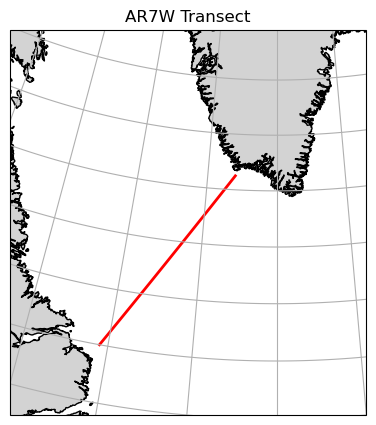

In [37]:
# plot transect

fig = plt.figure(figsize=(5, 5))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-45))
ax.set_extent([-60, -40, 52, 65], crs=ccrs.PlateCarree())  # Greenland region

# Add features
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.gridlines(draw_labels=False)

# Plot of unstructured points
plt.plot(transect.lon, 
         transect.lat,
         color='r',linewidth=2,
         transform=ccrs.PlateCarree())

# plot bathy
# bathy_greenland.plot(cmap='viridis',
#                      vmin=-3000,vmax=0,
#                      transform=ccrs.PlateCarree())

plt.title(f"AR7W Transect")
plt.show()

In [38]:
transect.to_netcdf('~/efs-mount-point/mzahn/data/ar7w/llc1080_etan_ar7w_transect.nc')

### Isolate transect data from ETAN with linear trend and seasonal cycle removed

In [ ]:
# -----------------------------
# 1. Define transect endpoints
# -----------------------------
lat1, lon1 = 54.0, -55.5
lat2, lon2 = 60.5, -48.0

geod = Geod(ellps="WGS84")

# total distance
_, _, total_dist = geod.inv(lon1, lat1, lon2, lat2)

spacing = 10_000  # 10 km
npts = int(total_dist // spacing) + 1

# intermediate geodesic points
pts = geod.npts(lon1, lat1, lon2, lat2, npts - 2)

lons = np.array([lon1] + [p[0] for p in pts] + [lon2])
lats = np.array([lat1] + [p[1] for p in pts] + [lat2])

# -----------------------------
# 2. Distance along transect
# -----------------------------
dist = np.zeros(len(lons))
for i in range(1, len(lons)):
    _, _, d = geod.inv(lons[i-1], lats[i-1], lons[i], lats[i])
    dist[i] = dist[i-1] + d

dist_km = dist / 1000

# -----------------------------
# 3. Prepare interpolation grid
# -----------------------------
XC = etan_da.XC.values
YC = etan_da.YC.values

points = np.column_stack([
    XC.ravel(),
    YC.ravel()])

target = np.column_stack([lons, lats])

# -----------------------------
# 4. Interpolate each timestep
# -----------------------------
out = np.empty((etan_da.time.size, len(lons)))

for i in range(etan_da.time.size):
    values = etan_da.isel(time=i).values.ravel()

    out[i] = griddata(
        points,
        values,
        target,
        method="linear")

# -----------------------------
# 5. Convert to xarray
# -----------------------------
transect = xr.DataArray(
    out,
    dims=("time", "distance_km"),
    coords=dict(
        time=etan_da.time,
        distance_km=dist_km,
        lat=("distance_km", lats),
        lon=("distance_km", lons),
    ),
    name="etan_transect")

In [121]:
# open bathymetry
gebco_bathy_ds = xr.open_dataset('~/efs-mount-point/mzahn/data/bathy/gebco_2021_sub_ice_n90.0_s30.0_w-120.0_e30.0.nc')
bathy_greenland = gebco_bathy_ds.elevation.sel(lon=slice(-65,-35),lat=slice(50,70))

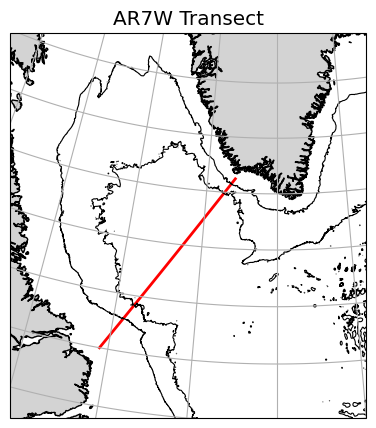

In [123]:
# plot transect

fig = plt.figure(figsize=(5, 5))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-45))
ax.set_extent([-60, -40, 52, 65], crs=ccrs.PlateCarree())  # Greenland region

# Add features
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.gridlines(draw_labels=False)

# Plot of unstructured points
plt.plot(transect.lon, 
         transect.lat,
         color='r',linewidth=2,
         transform=ccrs.PlateCarree())

# Bathymetry contours
bathy_levels = [-3000, -1000]

cs = ax.contour(
    bathy_greenland.lon,
    bathy_greenland.lat,
    bathy_greenland,
    levels=bathy_levels,
    colors="black",
    linewidths=0.8,
    linestyles="solid",
    transform=ccrs.PlateCarree()
)

plt.title(f"AR7W Transect")
plt.show()

In [38]:
transect.to_netcdf('~/efs-mount-point/mzahn/data/ar7w/llc1080_ar7w_transect.nc')

## Open transect dataset and plot average and ST of May-July

In [79]:
transect = xr.open_dataset('~/efs-mount-point/mzahn/data/ar7w/llc1080_etan_ar7w_transect.nc').etan_transect

In [80]:
# detrend and remove seasonal cycle along the transect
p = transect.polyfit(dim='time', deg=1)
linear_fit = xr.polyval(transect.time, p.polyfit_coefficients)
transect_detrended = transect - linear_fit

seasonal_cycle = transect_detrended.groupby('time.month').mean('time')
transect_anomaly = transect_detrended.groupby('time.month') - seasonal_cycle

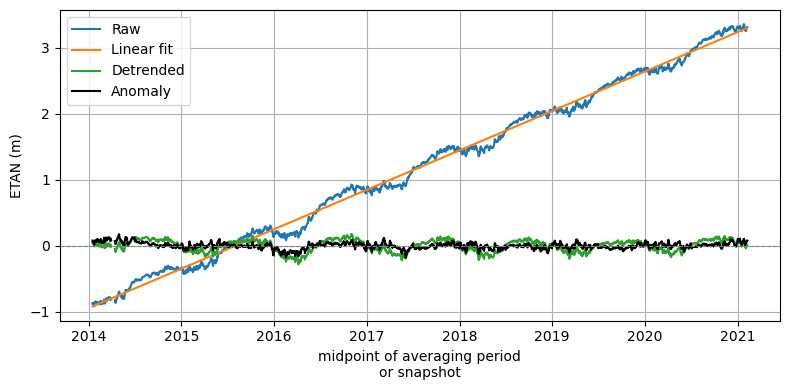

In [81]:
fig, ax = plt.subplots(figsize=(8, 4))

transect.mean('distance_km').plot(ax=ax, label='Raw')
linear_fit.mean('distance_km').plot(ax=ax, label='Linear fit')
transect_detrended.mean('distance_km').plot(ax=ax, label='Detrended')
transect_anomaly.mean('distance_km').plot(ax=ax, label='Anomaly', color='k')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylabel('ETAN (m)')
ax.legend()
ax.grid()
plt.tight_layout()

In [82]:
# transect_summer = transect.sel(time=transect.time.dt.month.isin([5, 6, 7]))
transect_anomaly_summer = transect_anomaly.sel(time=transect_anomaly.time.dt.month.isin([5, 6, 7]))

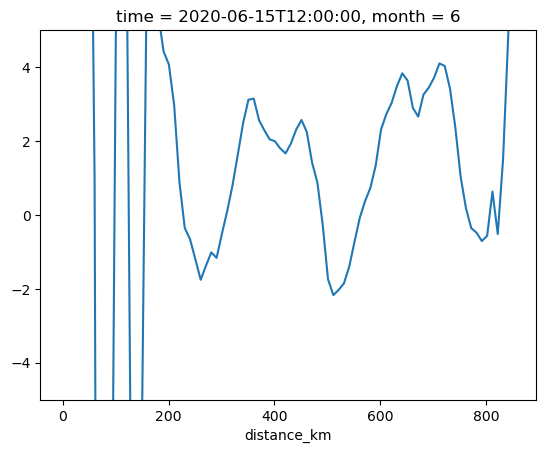

In [92]:
(transect_anomaly_summer.sel(time='2020-06-15')*100).plot();
plt.ylim(-5,5);

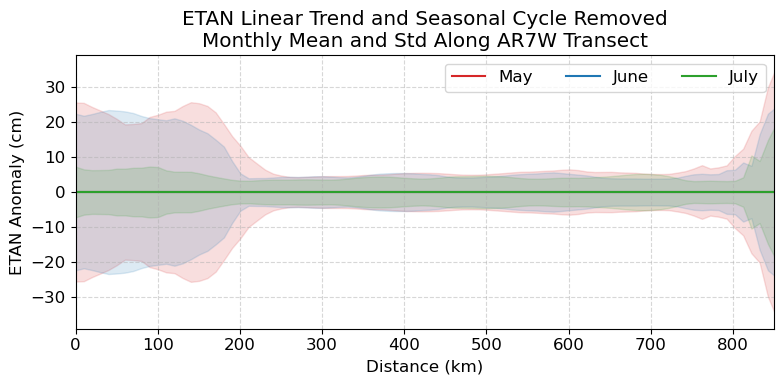

In [109]:
plt.rcParams['font.size'] = 12

# Group by month and compute mean and std
transect_summer_mean = transect_anomaly_summer.groupby('time.month').mean('time')
transect_summer_std = transect_anomaly_summer.groupby('time.month').std('time')

month_names = {5: 'May', 6: 'June', 7: 'July'}
colors = {5: 'tab:red', 6: 'tab:blue', 7: 'tab:green'}

fig, ax = plt.subplots(figsize=(8, 4))

for month in [5, 6, 7]:
    mean = transect_summer_mean.sel(month=month)*100
    std = transect_summer_std.sel(month=month)*100
    dist = transect_anomaly_summer.distance_km

    ax.plot(dist, mean, label=month_names[month], color=colors[month])
    ax.fill_between(dist, mean - std, mean + std, alpha=0.15, color=colors[month])

ax.set_title('ETAN Linear Trend and Seasonal Cycle Removed\nMonthly Mean and Std Along AR7W Transect')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('ETAN Anomaly (cm)')
ax.set_xlim(0,850)
ax.legend(ncol=3)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

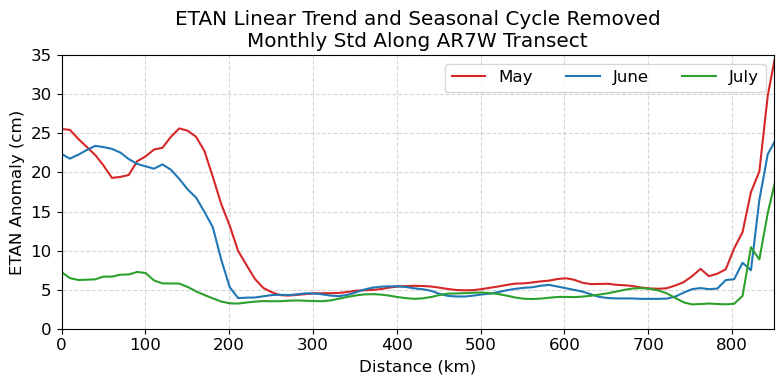

In [111]:
plt.rcParams['font.size'] = 12

# Group by month and compute mean and std
transect_summer_mean = transect_anomaly_summer.groupby('time.month').mean('time')
transect_summer_std = transect_anomaly_summer.groupby('time.month').std('time')

month_names = {5: 'May', 6: 'June', 7: 'July'}
colors = {5: 'tab:red', 6: 'tab:blue', 7: 'tab:green'}

fig, ax = plt.subplots(figsize=(8, 4))

for month in [5, 6, 7]:
    std = transect_summer_std.sel(month=month)*100
    dist = transect_anomaly_summer.distance_km

    ax.plot(dist, std, label=month_names[month], color=colors[month])

ax.set_title('ETAN Linear Trend and Seasonal Cycle Removed\nMonthly Std Along AR7W Transect')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('ETAN Anomaly (cm)')
ax.set_xlim(0,850)
ax.set_ylim(0,35)
ax.legend(ncol=3)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Subsample model for same dates as CTD data

In [156]:
# open ctd data
ctd_ds = xr.open_dataset('~/efs-mount-point/mzahn/data/ar7w/igor_ar7w.nc')

In [162]:
ctd_2019_ds = ctd_ds.sel(time='2019')

In [166]:
from pyresample import geometry, kd_tree

# Define the transect as a swath (1D along distance_km)
transect_grid = geometry.SwathDefinition(
    lons=transect_anomaly.lon.values,  # 1D along transect
    lats=transect_anomaly.lat.values   # 1D along transect
)

# Define CTD locations
ctd_grid = geometry.SwathDefinition(
    lons=ctd_2019_ds.longitude.values,
    lats=ctd_2019_ds.latitude.values
)

# Find nearest neighbour along transect for each CTD
_, _, idx, _ = kd_tree.get_neighbour_info(
    transect_grid, ctd_grid,
    radius_of_influence=50000,
    neighbours=1
)

# Now subsample transect at CTD locations and times
model_profiles = []

for n in range(len(ctd_2019_ds.time)):
    profile = transect_anomaly.isel(distance_km=idx[n]).sel(
        time=ctd_2019_ds.time.isel(time=n).values,
        method='nearest'
    )
    model_profiles.append(profile)

model_subsampled = xr.concat(model_profiles, dim='time')

In [167]:
model_subsampled

<xarray.DataArray (time: 40)> Size: 320B
array([ 0.12771141,  0.12714522, -0.04765456, -0.03264394, -0.04929912,
       -0.02572988, -0.04748691, -0.05789959, -0.01848289, -0.01470769,
        0.01088667, -0.0267645 , -0.03636157, -0.03685069, -0.0301874 ,
       -0.00542417,  0.02261808,  0.02711871,  0.02809585,  0.00243449,
        0.00856688, -0.00543811, -0.01132248, -0.00687289,  0.01798056,
        0.02709225,  0.07992156,  0.01427274, -0.00450372,  0.00539031,
        0.00403689, -0.07492792, -0.05679033, -0.02980266, -0.07127597,
        0.03539206,  0.08572499,  0.09830901,  0.10856874,  0.01412518])
Coordinates:
  * time         (time) datetime64[ns] 320B 2019-06-09T12:00:00 ... 2019-06-2...
    distance_km  (time) float64 320B 0.0 10.03 40.12 210.6 ... 110.3 70.21 200.6
    lat          (time) float64 320B 54.0 54.08 54.32 ... 54.86 54.55 55.57
    lon          (time) float64 320B -55.5 -55.43 -55.2 ... -54.67 -54.98 -53.96
    month        int64 8B 6

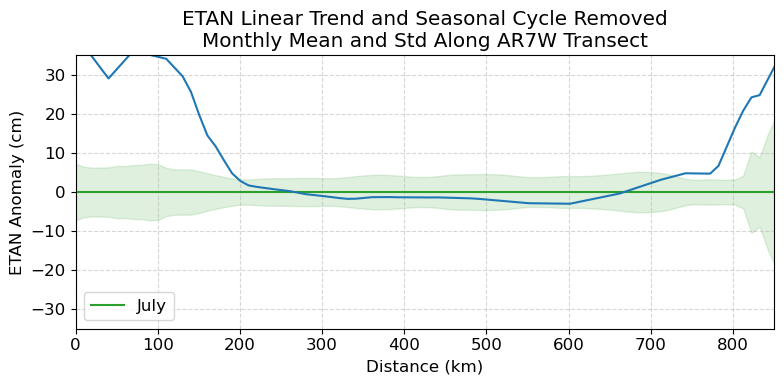

In [141]:
plt.rcParams['font.size'] = 12

# Group by month and compute mean and std
transect_summer_mean = transect_anomaly_summer.groupby('time.month').mean('time')
transect_summer_std = transect_anomaly_summer.groupby('time.month').std('time')

month_names = {5: 'May', 6: 'June', 7: 'July'}
colors = {5: 'tab:red', 6: 'tab:blue', 7: 'tab:green'}

fig, ax = plt.subplots(figsize=(8, 4))

for month in [7]:
    mean = transect_summer_mean.sel(month=month)*100
    std = transect_summer_std.sel(month=month)*100
    dist = transect_anomaly_summer.distance_km

    ax.plot(dist, mean, label=month_names[month], color=colors[month])
    ax.fill_between(dist, mean - std, mean + std, alpha=0.15, color=colors[month])

(model_subsampled.sortby('distance_km')*100).plot(ax=ax, x='distance_km');

ax.set_title('ETAN Linear Trend and Seasonal Cycle Removed\nMonthly Mean and Std Along AR7W Transect')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('ETAN Anomaly (cm)')
ax.set_xlim(0,850)
ax.set_ylim(-35,35)
ax.legend(ncol=3)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Select model timesteps that match your in situ sampling dates
transect_subsampled = transect_anomaly.sel(time=insitu_dates, method='nearest')

# Compare std of subsampled vs full record
subsampled_std = transect_subsampled.std(dim='time')
full_std = transect_anomaly.std(dim='time')